# E2.3 – Risk Decision Model

This is the **third and final FMFD** in the *Decoding Risk* project.

We load the client and transaction embeddings produced in Notebooks 1 and 2, concatenate them
into a single feature vector, and train a classifier that mirrors what a bank's risk-decision
engine would do.  The key insight: the model never sees raw fields — only embeddings.

**What we do here:**
1. Load client and transaction embeddings
2. Pair them up and assign synthetic risk labels
3. Concatenate the two embedding vectors into one feature
4. Train a gradient-boosted classifier (and compare with logistic regression)
5. Evaluate: accuracy, confusion matrix, classification report
6. Demo multi-output prediction (approval + default probability + recommended rate)
7. End-to-end inference: new customer request → risk decision

> **Prerequisites:** Run Notebooks 1 and 2 first so the `.pkl` files exist.


---
**Author:** Adebanji Oluwatimileyin Adelowo  
**GitHub:** [adebanjiadelowo](https://github.com/adebanjiadelowo)

In [1]:
import numpy as np
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

from sentence_transformers import SentenceTransformer

random.seed(42)
np.random.seed(42)

## 1 – Load embeddings from Notebooks 1 & 2

In [2]:
with open('client_embeddings.pkl', 'rb') as f:
    client_data = pickle.load(f)

with open('transaction_embeddings.pkl', 'rb') as f:
    txn_data = pickle.load(f)

client_embs = client_data['embeddings']          # (500, 384)
client_meta = pd.DataFrame(client_data['metadata'])

txn_embs    = txn_data['embeddings']             # (500, 384)
txn_meta    = pd.DataFrame(txn_data['metadata'])

print('Client embeddings :', client_embs.shape)
print('Transaction embeddings:', txn_embs.shape)
print()
print('Client metadata columns  :', list(client_meta.columns))
print('Transaction metadata columns:', list(txn_meta.columns))

Client embeddings : (500, 384)
Transaction embeddings: (500, 384)

Client metadata columns  : ['customer_id', 'age', 'annual_income', 'credit_score', 'account_balance', 'num_credit_cards', 'employment_years', 'employment_type', 'num_prev_loans', 'previous_default', 'monthly_expenses', 'num_dependents', 'debt_to_income']
Transaction metadata columns: ['transaction_id', 'customer_id', 'product_id', 'product_type', 'amount', 'term_months', 'interest_rate', 'collateral', 'risk_level']


## 2 – Create training pairs

Each training sample is one (customer, transaction) pair.  We match transaction `i` to a
randomly selected customer.  The risk label is derived from a simple rule engine that
approximates what a real underwriting model would decide.

In [3]:
RISK_LEVELS = {'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}

def assign_label(client_row, txn_row):
    """
    Heuristic underwriting rule.
    Returns (approved: int, default_prob: float, recommended_rate: float).
    """
    score   = int(client_row['credit_score'])
    income  = int(client_row['annual_income'])
    dti     = float(client_row['debt_to_income'])
    default = int(client_row['previous_default'])
    amount  = int(txn_row['amount'])
    rate    = float(txn_row['interest_rate'])
    prod_risk = RISK_LEVELS.get(txn_row['risk_level'], 1)

    # Rejection conditions
    if score < 500:
        return 0, 0.75, rate + 4.0
    if default == 1 and score < 650:
        return 0, 0.60, rate + 3.0
    if dti > 0.6:
        return 0, 0.55, rate + 2.5
    if amount > income * 5:
        return 0, 0.50, rate + 2.0

    # Approval – compute default probability and adjusted rate
    base_prob = max(0.01, (800 - score) / 800)
    default_prob = min(0.95, base_prob + prod_risk * 0.05 + dti * 0.1)
    adj_rate = rate + (800 - score) / 200 + prod_risk * 0.25

    return 1, round(default_prob, 3), round(adj_rate, 2)


records = []
for i in range(len(txn_meta)):
    cust_id  = txn_meta.iloc[i]['customer_id']
    cust_idx = client_meta.index[client_meta['customer_id'] == cust_id]

    # Fall back to random customer if the ID isn't in our 500
    if len(cust_idx) == 0:
        cust_idx = [random.randint(0, len(client_meta) - 1)]

    ci = int(cust_idx[0])
    approved, default_prob, adj_rate = assign_label(client_meta.iloc[ci], txn_meta.iloc[i])

    records.append({
        'client_idx':    ci,
        'txn_idx':       i,
        'approved':      approved,
        'default_prob':  default_prob,
        'adj_rate':      adj_rate,
    })

labels_df = pd.DataFrame(records)
print('Training samples:', len(labels_df))
print('Approval rate: {:.1f}%'.format(labels_df['approved'].mean() * 100))
labels_df.head()

Training samples: 500
Approval rate: 33.4%


,client_idx,txn_idx,approved,default_prob,adj_rate
0,114,0,1,0.189,4.68
1,279,1,0,0.550,10.62
2,47,2,0,0.750,7.30
3,287,3,0,0.550,10.81
4,214,4,1,0.161,8.99


## 3 – Build the feature matrix

We concatenate the two 384-dim vectors → one 768-dim input for the classifier.

This is the key architectural choice described in the README: by concatenating fixed-length
embeddings we always get the same input dimensionality regardless of how many raw fields
the underlying data sources contain.

In [4]:
client_vecs = client_embs[labels_df['client_idx'].values]
txn_vecs    = txn_embs[labels_df['txn_idx'].values]

X = np.concatenate([client_vecs, txn_vecs], axis=1)
y = labels_df['approved'].values

print('Feature matrix X:', X.shape)   # (500, 768)
print('Labels y        :', y.shape)
print('Class balance   – Approved: {}  |  Rejected: {}'.format(
    int(y.sum()), int((1 - y).sum())))

Feature matrix X: (500, 768)
Labels y        : (500,)
Class balance   – Approved: 167  |  Rejected: 333


## 4 – Train / test split

In [5]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, labels_df.index.values,
    test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])

Train size: 400
Test size : 100


## 5 – Train classifiers

We compare a simple logistic regression baseline with an XGBoost gradient-boosted model.
Both consume only the concatenated embeddings — no raw features ever enter the model.
The embeddings are unit-norm, so each of the 768 features varies by only about 0.016. With
scikit-learn's default regularisation (`C=1`) on features this small, logistic regression is so
strongly shrunk that every predicted probability stays below 0.5 and it predicts "Rejected" for
everyone. The features are therefore standardised, and `C` is chosen by 5-fold cross-validation on
the training split only.


In [6]:
# --- Logistic Regression baseline ---
# Standardise the embedding features and choose the regularisation strength C by stratified
# 5-fold cross-validation on the training split only (the test split is not used for tuning).
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import warnings

# LogisticRegressionCV emits FutureWarnings about API changes in newer scikit-learn releases
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')

lr = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        Cs=np.logspace(-4, 2, 13),
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='roc_auc', max_iter=5000,
    ),
)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print('C chosen by cross-validation on the training split: {:.4g}'.format(lr[-1].C_[0]))
print('Accuracy : {:.4f}'.format(accuracy_score(y_test, lr_preds)))
print('ROC-AUC  : {:.4f}'.format(roc_auc_score(y_test, lr_probs)))
print()


=== Logistic Regression ===
C chosen by cross-validation on the training split: 0.3162
Accuracy : 0.9100
ROC-AUC  : 0.9408



In [7]:
# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, verbosity=0
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

print('=== XGBoost ===')
print('Accuracy : {:.4f}'.format(accuracy_score(y_test, xgb_preds)))
print('ROC-AUC  : {:.4f}'.format(roc_auc_score(y_test, xgb_probs)))

=== XGBoost ===
Accuracy : 0.9300
ROC-AUC  : 0.9742


## 6 – Evaluate in detail

In [8]:
print('=== Classification Report (XGBoost) ===')
print(classification_report(y_test, xgb_preds, target_names=['Rejected', 'Approved']))

=== Classification Report (XGBoost) ===
              precision    recall  f1-score   support

    Rejected       0.97      0.93      0.95        67
    Approved       0.86      0.94      0.90        33

    accuracy                           0.93       100
   macro avg       0.91      0.93      0.92       100
weighted avg       0.93      0.93      0.93       100



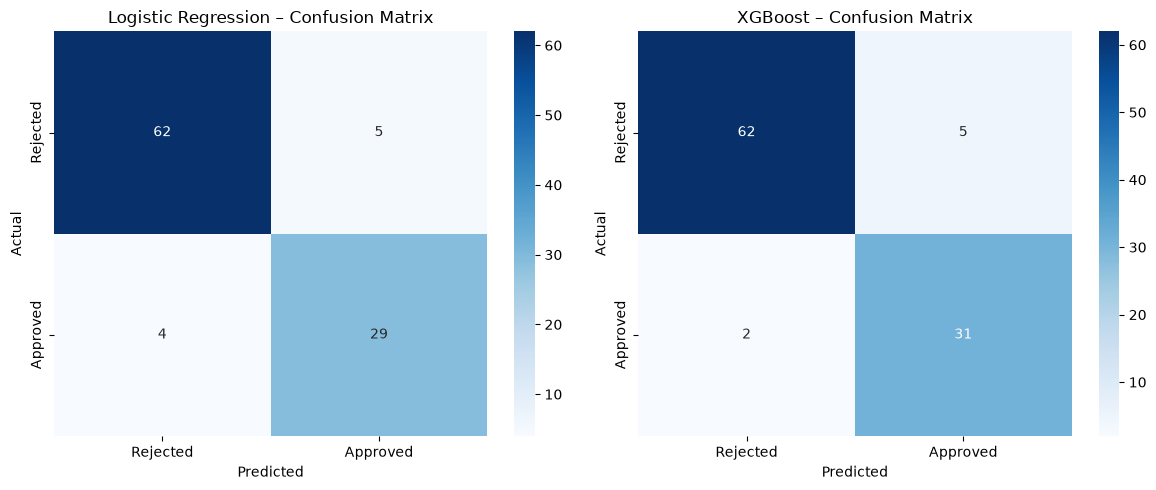

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [lr_preds, xgb_preds],
    ['Logistic Regression', 'XGBoost']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Rejected', 'Approved'],
        yticklabels=['Rejected', 'Approved'],
    )
    ax.set_title('{} – Confusion Matrix'.format(title))
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Metrics against a majority-class baseline

About two thirds of cases are rejections, so accuracy alone is misleading: always predicting
"Rejected" already scores about 0.67. Balanced accuracy and precision/recall/F1 on the approved class
show whether a model has learned anything beyond the class prior.


In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import balanced_accuracy_score, precision_recall_fscore_support

majority = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)

rows = []
for name, preds, probs in [
    ('Majority class', majority.predict(X_test), None),
    ('Logistic Regression', lr_preds, lr_probs),
    ('XGBoost', xgb_preds, xgb_probs),
]:
    p, r, f, _ = precision_recall_fscore_support(y_test, preds, labels=[1], zero_division=0)
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, preds),
        'balanced_accuracy': balanced_accuracy_score(y_test, preds),
        'approved_precision': p[0], 'approved_recall': r[0], 'approved_f1': f[0],
        'roc_auc': roc_auc_score(y_test, probs) if probs is not None else float('nan'),
    })
pd.DataFrame(rows).set_index('model').round(3)


,accuracy,balanced_accuracy,approved_precision,approved_recall,approved_f1,roc_auc
model,,,,,,
Majority class,0.67,0.500,0.000,0.000,0.000,NaN
Logistic Regression,0.91,0.902,0.853,0.879,0.866,0.941
XGBoost,0.93,0.932,0.861,0.939,0.899,0.974


### Check: customers shared between train and test

The split above is over (customer, transaction) rows, and many customers have several transactions,
so most test rows belong to a customer the models were trained on. The labelling rule depends mostly
on customer attributes, so this can inflate test scores. Below, both models are re-evaluated with
5-fold cross-validation grouped by customer, so no customer appears in both the training and the
evaluation fold. This is the relevant estimate for scoring a new customer.


In [11]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict

groups = labels_df['client_idx'].values
shared = np.isin(labels_df.loc[idx_test, 'client_idx'], labels_df.loc[idx_train, 'client_idx']).sum()
print('Test rows whose customer also appears in the training split: {}/{}'.format(shared, len(idx_test)))

grouped_cv = StratifiedGroupKFold(5, shuffle=True, random_state=42)
rows = []
for name, model in [('Majority class', majority), ('Logistic Regression', lr), ('XGBoost', xgb)]:
    probs = cross_val_predict(clone(model), X, y, cv=grouped_cv, groups=groups, method='predict_proba')[:, 1]
    preds = (probs > 0.5).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y, preds, labels=[1], zero_division=0)
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y, preds),
        'balanced_accuracy': balanced_accuracy_score(y, preds),
        'approved_precision': p[0], 'approved_recall': r[0], 'approved_f1': f[0],
        'roc_auc': roc_auc_score(y, probs) if name != 'Majority class' else float('nan'),
    })
pd.DataFrame(rows).set_index('model').round(3)


Test rows whose customer also appears in the training split: 66/100


,accuracy,balanced_accuracy,approved_precision,approved_recall,approved_f1,roc_auc
model,,,,,,
Majority class,0.666,0.500,0.000,0.000,0.000,NaN
Logistic Regression,0.782,0.750,0.681,0.653,0.667,0.817
XGBoost,0.718,0.644,0.614,0.419,0.498,0.759


A single grouped split can be lucky or unlucky, so the grouped cross-validation is repeated
with 10 different fold assignments. This measures sensitivity to how customers are allocated to folds
on this one synthetic dataset; it says nothing about other datasets, and XGBoost's hyperparameters are
the notebook's fixed values, not tuned.


In [12]:
rows = []
for fold_seed in range(10):
    cv = StratifiedGroupKFold(5, shuffle=True, random_state=fold_seed)
    row = {'fold_seed': fold_seed}
    for name, model in [('Logistic Regression', lr), ('XGBoost', xgb)]:
        probs = cross_val_predict(clone(model), X, y, cv=cv, groups=groups, method='predict_proba')[:, 1]
        row[name + ' balanced_accuracy'] = balanced_accuracy_score(y, (probs > 0.5).astype(int))
        row[name + ' roc_auc'] = roc_auc_score(y, probs)
    rows.append(row)
repeats = pd.DataFrame(rows).set_index('fold_seed')
diff = repeats['Logistic Regression balanced_accuracy'] - repeats['XGBoost balanced_accuracy']
print('Logistic Regression minus XGBoost balanced accuracy: mean {:.3f}, range {:.3f} to {:.3f}, '
      'positive in {}/{} fold assignments'.format(diff.mean(), diff.min(), diff.max(), int((diff > 0).sum()), len(diff)))
repeats.agg(['mean', 'std', 'min', 'max']).round(3)


Logistic Regression minus XGBoost balanced accuracy: mean 0.099, range 0.052 to 0.142, positive in 10/10 fold assignments


,Logistic Regression balanced_accuracy,Logistic Regression roc_auc,XGBoost balanced_accuracy,XGBoost roc_auc
mean,0.736,0.813,0.637,0.770
std,0.019,0.015,0.023,0.019
min,0.714,0.780,0.608,0.730
max,0.772,0.836,0.672,0.797


## 7 – Multi-output prediction

One advantage of the embedding architecture mentioned in the README is that a single model call
can return **multiple** pieces of information.  Here we simulate that: given the same 768-dim
input, we predict approval, default probability, and a recommended interest-rate adjustment.

In [13]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# Build multi-output targets
y_multi = labels_df.loc[
    [labels_df.index[i] for i in range(len(labels_df))],
    ['approved', 'default_prob', 'adj_rate']
].values

y_multi_train = y_multi[idx_train]
y_multi_test  = y_multi[idx_test]

mo_model = MultiOutputRegressor(
    GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
)
mo_model.fit(X_train, y_multi_train)
mo_preds = mo_model.predict(X_test)

print('Multi-output model MAEs:')
for col_idx, col_name in enumerate(['Approval score', 'Default probability', 'Recommended rate']):
    mae = mean_absolute_error(y_multi_test[:, col_idx], mo_preds[:, col_idx])
    print('  {}: {:.4f}'.format(col_name, mae))

Multi-output model MAEs:
  Approval score: 0.1465
  Default probability: 0.0597
  Recommended rate: 1.1598


## 8 – End-to-end inference demo

This cell simulates what happens in production: a new loan request arrives, we embed both
the customer and the transaction on the fly, concatenate them, and run the risk model.

In [14]:
model_st = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')


# Inference must embed exactly the same text as training (notebooks 01 and 02), so the text is
# built by the same functions.
from profile_text import customer_to_text, transaction_to_text


def embed_customer(profile: dict) -> np.ndarray:
    return model_st.encode([customer_to_text(profile)])[0]


def embed_transaction(txn: dict) -> np.ndarray:
    return model_st.encode([transaction_to_text(txn)])[0]


def risk_decision(customer: dict, transaction: dict) -> dict:
    c_emb = embed_customer(customer)
    t_emb = embed_transaction(transaction)
    feat  = np.concatenate([c_emb, t_emb]).reshape(1, -1)

    # Binary approval from XGBoost
    approved_prob = float(xgb.predict_proba(feat)[0][1])
    approved      = approved_prob >= 0.5

    # Continuous outputs from multi-output model
    mo_out = mo_model.predict(feat)[0]

    return {
        'approved':         bool(approved),
        'approval_score':   round(approved_prob, 3),
        'default_prob':     round(float(max(0, min(1, mo_out[1]))), 3),
        'recommended_rate': round(float(max(0, mo_out[2])), 2),
    }


# --- Demo 1: Strong customer, low-risk product ---
strong_customer = {
    'age': 40, 'annual_income': 120_000, 'credit_score': 780,
    'account_balance': 25_000, 'num_credit_cards': 2,
    'employment_years': 12, 'employment_type': 'Employed',
    'num_prev_loans': 3, 'previous_default': 0,
    'monthly_expenses': 3_500, 'num_dependents': 2,
    'debt_to_income': round(3_500 * 12 / 120_000, 2),
}

personal_loan = {
    'product_type': 'Personal Loan', 'amount': 15_000,
    'term_months': 36, 'interest_rate': 8.5,
    'collateral': False, 'risk_level': 'Medium',
}

result1 = risk_decision(strong_customer, personal_loan)
print('=== Demo 1: Strong customer + Personal Loan ===')
for k, v in result1.items():
    print('  {}: {}'.format(k, v))
print('  labelling rule (assign_label): approved = {}'.format(bool(assign_label(strong_customer, personal_loan)[0])))

print()

# --- Demo 2: Weak customer, high-risk product ---
weak_customer = {
    'age': 25, 'annual_income': 22_000, 'credit_score': 490,
    'account_balance': 800, 'num_credit_cards': 4,
    'employment_years': 1, 'employment_type': 'Self-employed',
    'num_prev_loans': 6, 'previous_default': 1,
    'monthly_expenses': 2_800, 'num_dependents': 1,
    'debt_to_income': round(2_800 * 12 / 22_000, 2),
}

business_loan = {
    'product_type': 'Business Loan', 'amount': 80_000,
    'term_months': 60, 'interest_rate': 9.5,
    'collateral': True, 'risk_level': 'High',
}

result2 = risk_decision(weak_customer, business_loan)
print('=== Demo 2: Weak customer + Business Loan ===')
for k, v in result2.items():
    print('  {}: {}'.format(k, v))
print('  labelling rule (assign_label): approved = {}'.format(bool(assign_label(weak_customer, business_loan)[0])))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8996.53it/s]


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== Demo 1: Strong customer + Personal Loan ===
  approved: False
  approval_score: 0.378
  default_prob: 0.298
  recommended_rate: 12.04
  labelling rule (assign_label): approved = True

=== Demo 2: Weak customer + Business Loan ===
  approved: False
  approval_score: 0.054
  default_prob: 0.455
  recommended_rate: 10.7
  labelling rule (assign_label): approved = False


## Summary

We have demonstrated the full *Decoding Risk* pipeline end-to-end:

| Step | Notebook | Output |
|------|----------|--------|
| Client FMFD | E2_1 | `client_embeddings.pkl` (500 × 384) |
| Product FMFD | E2_2 | `transaction_embeddings.pkl` (500 × 384) |
| Decision FMFD | E2_3 | XGBoost + multi-output regressor |

**Key takeaways:**
- Every system boundary passes 384-dim vectors, not raw fields.
- The same classifier accepts any customer/product combination without schema changes. How well it
  scores *new* customers is measured by the customer-grouped check in section 6, which is well below
  the row-level test-split scores.
- A single model call returns approval decision, default probability, and recommended rate simultaneously.
- Embeddings are compact enough to be stored on-device for offline scoring.

**Production next steps:**
- Replace `all-MiniLM-L6-v2` with a domain-specific model fine-tuned via QLoRA on real banking data (see README, FinGPT reference).
- Add a real-time embedding update pipeline so client vectors reflect the latest transactions.
- Introduce fairness auditing on the decision model outputs.